# Trabajo Nº1 – Clasificación de Perros y Gatos con CNN y Transfer Learning

Este notebook sirve como plantilla mínima para que puedas comenzar a construir tus propias CNN y aplicar Transfer Learning.  
Incluye:
- Configuración básica e imports.
- Carga de imágenes desde carpetas (`Cats_Dogs/cat` y `Cats_Dogs/dog`) y redimensionado a tamaño fijo.
- Celda final para generar el `.csv` de predicciones con el formato requerido.

Indicaciones:
- En la entrega se proporciona `Cats_Dogs.zip` con 1000 imágenes por clase (carpetas `cat` y `dog`).  
- Descomprime el zip en el mismo directorio del notebook antes de ejecutar.
- Tú debes definir y entrenar tu modelo (CNN propia y un modelo de Transfer Learning).  
- Al final, genera `predicciones_cats_dogs.csv` con el formato especificado.

In [1]:
# Añade aquí los import que utilices en tu código
import os
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.20.0


## Carga de Imágenes

Se cargan exactamente **1000 imágenes de cada clase** desde la carpeta `Cats_Dogs`, asumiendo esta estructura:

```text
Cats_Dogs/
├─ cat/
│  ├─ 0.jpg
│  ├─ ...
├─ dog/
│  ├─ 0.jpg
│  ├─ ...
```

Preprocesamiento:
- Redimensionado a `224×224` píxeles (puedes cambiar `IMG_SIZE` si lo justificas).
- Conversión a RGB.

Las etiquetas se almacenan como enteros:
- `0` → gato  
- `1` → perro

In [2]:
# Configuración de rutas y parámetros
DATASET_DIR = pathlib.Path("Cats_Dogs")  # Cambia si usas otra ruta
IMAGE_SIZE = (180, 180)
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    shuffle=True,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    shuffle=True,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names

Found 1371 files belonging to 2 classes.
Using 1097 files for training.
Found 1371 files belonging to 2 classes.
Using 274 files for validation.


## Desarrollo de la Práctica

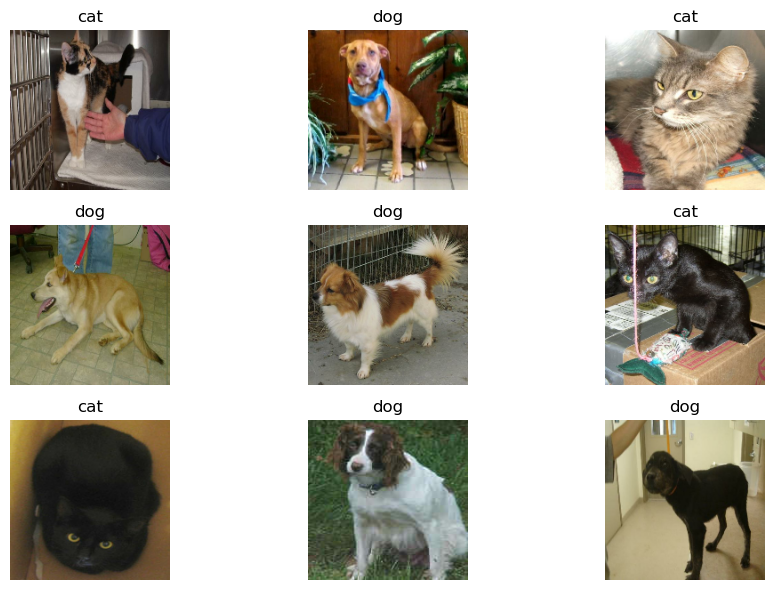

In [3]:
plt.figure(figsize=(10, 6))           # Para ver si se han cargado bien las imagenes
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
#DEFINICION DE MI CNN

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.05, seed=SEED),
    ],
    name="data_augmentation",
)

model = keras.Sequential(
    [
        keras.Input(shape=(*IMAGE_SIZE, 3)),
        data_augmentation,
        layers.Rescaling(1.0 / 255),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Dropout(0.3),
        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="cnn_basica_cyd",
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "cnn_basica_cyd"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)       │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 180, 180, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 90, 90, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 90, 90, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 45, 45, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 45, 45, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 22, 22, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 22, 22, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 22, 22, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 11, 11, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 15488)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       3,965,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,206,273 (16.05 MB)

 Trainable params: 4,206,273 (16.05 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
#Entrenamos con callbacks

CHECKPOINT_DIR = pathlib.Path("model_checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)
CHECKPOINT_PATH = CHECKPOINT_DIR / "cnn_basica.keras"

callbacks = [
    keras.callbacks.EarlyStopping(           # para frenar el entrenamiento cuando la validacion deje de mejorar
        monitor="val_loss", patience=5, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(              #para bajar la tasa de aprendizaje si la perdida se estanca
        monitor="val_loss", factor=0.5, patience=3, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(         # para guardar el mejor modelo
        filepath=CHECKPOINT_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks,
    verbose=1,
)

history_df = pd.DataFrame(history.history)
history_df.tail()

Epoch 1/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.6792 - loss: 0.6793 
Epoch 1: val_accuracy improved from None to 0.68613, saving model to model_checkpoints\cnn_basica.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 15s 374ms/step - accuracy: 0.7238 - loss: 0.6217 - val_accuracy: 0.6861 - val_loss: 0.6373 - learning_rate: 0.0010
Epoch 2/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.7437 - loss: 0.5792 
Epoch 2: val_accuracy did not improve from 0.68613
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 361ms/step - accuracy: 0.7402 - loss: 0.5814 - val_accuracy: 0.6861 - val_loss: 0.6214 - learning_rate: 0.0010
Epoch 3/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.7365 - loss: 0.5788 
Epoch 3: val_accuracy did not improve from 0.68613
35/35 ━━━━━━━━━━━━━━━━━━━━ 21s 362ms/step - accuracy: 0.7402 - loss: 0.5759 - val_accuracy: 0.6861 - val_loss: 0.6102 - learning_rate: 0.0010
Epoch 4/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.7508 - loss: 0.5508 
Epoch 4: val_accurac

,accuracy,loss,val_accuracy,val_loss,learning_rate
12,0.762990,0.491939,0.744526,0.539675,0.0010
13,0.768459,0.482207,0.773723,0.495196,0.0010
14,0.801276,0.450170,0.799270,0.465977,0.0010
15,0.815861,0.419699,0.799270,0.465655,0.0005
16,0.814950,0.410140,0.791971,0.461398,0.0005


Accuracy: 0.7993
Pérdida: 0.4660


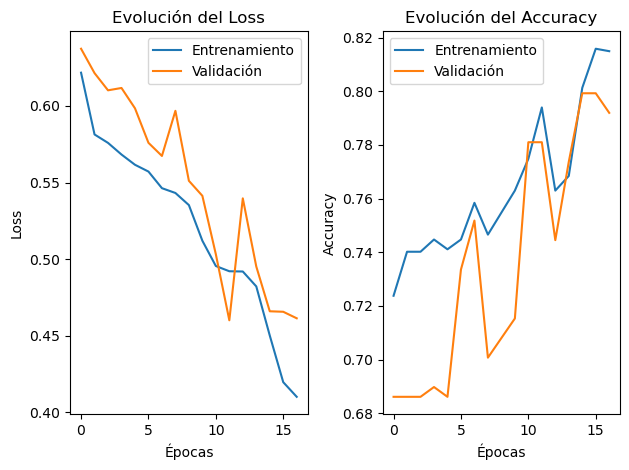

In [6]:
# evaluamos el analisis

best_model = keras.models.load_model(CHECKPOINT_PATH)
val_loss, val_acc = best_model.evaluate(val_ds, verbose=0)

print(f"Accuracy: {val_acc:.4f}")
print(f"Pérdida: {val_loss:.4f}")

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Evolución del Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Evolución del Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Generación del CSV final de Predicciones

Una vez **definido y entrenado tu modelo** (no incluido en esta plantilla) y separadas tus imágenes de prueba en `X_test`, genera el archivo `predicciones_cats_dogs.csv` con el siguiente formato:

```text
id,label
0,0
1,0
2,1
...
```

Donde:
- `id` es el índice (comenzando en 0) de la imagen de prueba.
- `label` es `0` para gato y `1` para perro.

Notas importantes:
- Esta celda asume que tu **modelo** tiene una **salida sigmoide** (`Dense(1, activation='sigmoid')`) y que dispones de un `X_test` con las imágenes de evaluación (preprocesadas igual que X).
- Si usas una salida softmax de 2 neuronas, adapta la conversión de `y_pred` a clases.

In [ ]:
# Generación de CSV de predicciones
# Requisitos previos:
# - Debes haber definido y entrenado tu 'model'
# - Debes tener preparado 'X_test' con el mismo preprocesamiento (224x224, RGB, normalizado)

# Obtener predicciones del modelo
y_pred = model.predict(X_test, verbose=0)

# Si tu salida es sigmoide (1 neurona → binaria)
y_pred_classes = (y_pred > 0.5).astype("int32").flatten()

# Crear DataFrame con el formato solicitado
df = pd.DataFrame({
    "id": np.arange(1, len(y_pred_classes) + 1),
    "label": y_pred_classes
})

# Guardar como CSV
output_path = "predicciones_cats_dogs.csv"
df.to_csv(output_path, index=False)

print(f"Archivo guardado correctamente como: {output_path}")
df.head()